In [336]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display
from matplotlib import ticker

pd.set_option('display.max_columns', None)

In [337]:
DATA_PATH = '../data/raw/ecommerce-data.csv'

sns.set_theme(style="whitegrid")

df = pd.read_csv(DATA_PATH, encoding='unicode_escape')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Phase 1: Data Overview

**Objective:** Establish baseline understanding of dataset size, structure, dtypes, and numeric ranges.

In [338]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nDuplicate columns:", df.columns[df.columns.duplicated()].tolist())
print("\nMemory usage (bytes):", df.memory_usage(deep=True).sum())

Shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Duplicate columns: []

Memory usage (bytes): 181533217


In [339]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [340]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [341]:
df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,6/1/2011 12:05,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,5/27/2011 17:14,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,4/21/2011 17:05,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,11/16/2011 10:39,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,3/10/2011 8:40,9.95,13502.0,United Kingdom


In [342]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [343]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [344]:
print(df[df['Quantity']<=0]['Quantity'].sort_values())

negative_quantity=(df['Quantity']<=0).sum()
print(f'\nNumber of negative value in Quantity feature: {negative_quantity}')

540422   -80995
61624    -74215
225529    -9600
225530    -9600
4287      -9360
          ...  
240697       -1
240696       -1
240694       -1
242447       -1
249284       -1
Name: Quantity, Length: 10624, dtype: int64

Number of negative value in Quantity feature: 10624


In [345]:
display(df[df['Quantity']<=0])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [346]:
neg_quantity_transactions = len(df[df['Quantity'] <= 0])

canceled_with_C_count = len(df[(df['Quantity'] <= 0) & (df['InvoiceNo'].astype(str).str.startswith('C'))])

cancel_transaction_begin_with_C_rate = canceled_with_C_count / neg_quantity_transactions

print(f"Rate: {cancel_transaction_begin_with_C_rate:.2%}")

Rate: 87.42%


In [347]:
display(df[df['UnitPrice']<=0])

negative_quantity=(df['UnitPrice']<=0).sum()
print(f'\nNumber of negative value in UnitPrice feature: {negative_quantity}')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom



Number of negative value in UnitPrice feature: 2517


In [348]:
df.loc[df['UnitPrice'] == 0, 'Description'].unique().tolist()

[nan,
 'amazon',
 '?',
 'ROUND CAKE TIN VINTAGE GREEN',
 'check',
 'damages',
 'CREAM SWEETHEART LETTER RACK',
 'ZINC WILLIE WINKIE  CANDLE STICK',
 'BOX OF 24 COCKTAIL PARASOLS',
 'DOORMAT ENGLISH ROSE ',
 'DOORMAT 3 SMILEY CATS',
 'GREEN REGENCY TEACUP AND SAUCER',
 'FRENCH BLUE METAL DOOR SIGN 7',
 'FRENCH BLUE METAL DOOR SIGN 5',
 'FRENCH BLUE METAL DOOR SIGN 6',
 'FRENCH BLUE METAL DOOR SIGN 4',
 'FRENCH BLUE METAL DOOR SIGN No',
 'FRENCH BLUE METAL DOOR SIGN 8',
 'FRENCH BLUE METAL DOOR SIGN 1',
 'RED KITCHEN SCALES',
 'IVORY KITCHEN SCALES',
 'SET OF 6 SOLDIER SKITTLES',
 'CHILDS GARDEN TROWEL BLUE ',
 'CHILDRENS GARDEN GLOVES BLUE',
 'PICNIC BASKET WICKER SMALL',
 'PICNIC BASKET WICKER LARGE',
 'EMPIRE UNION JACK TV DINNER TRAY',
 'TV DINNER TRAY VINTAGE PAISLEY',
 'SPACEBOY TV DINNER TRAY',
 'TV DINNER TRAY DOLLY GIRL',
 'CHILDS GARDEN SPADE BLUE',
 'CHILDS GARDEN RAKE BLUE',
 'WATERING CAN PINK BUNNY',
 'ENAMEL FIRE BUCKET CREAM',
 'ENAMEL FLOWER JUG CREAM',
 'AIRLINE BAG VIN

In [349]:
df['Quantity'].median()

np.float64(3.0)

In [350]:
df['Quantity'].quantile([0.75,0.8,0.85,0.9,0.95,0.97,0.99])

0.75     10.0
0.80     12.0
0.85     12.0
0.90     24.0
0.95     29.0
0.97     48.0
0.99    100.0
Name: Quantity, dtype: float64

## Observation about numeric feature

### Observation
- `Quantity` varies significantly, however, mostly under 10 (~75%). There may be some outlier in this feature
- There are some negative value in `Quantity` feature, mostly are the result of canceled transaction, which has the InvoiceNo starts with letter 'C'. Cancel transaction accounted for around 87% transactions with negative quantity.
- `UnitPrice` also varies, but at a lesser extent. 
- `UnitPrice` contains some non-positive value. 
- `CustomerID` feature contain a lot of null value

### Action
- In `Quantity` feature, we will split non-positive transaction into 2 part: cancelled and the rest. We will reuse cancelled transactions to generate other feature in feature engineering phase. The rest is meaninglessly descriptive because it might be one of the case: damaged goods, stock adjustment, testing transaction,etc. It is meaningless in customer segmentation, therefore, they will be dropped completely.
- All rows with non-positive value in `UnitPrice` may be resulted from mistake when recorded, adjustment stock, testing system, it is a gift, etc. Therefore, there are meaningless in customer segmentation, meaning that they will be dropped completely.
- We will drop null value in `CustomerID` because we grouping those who without the ID

In [351]:
df.describe(include='object')

/var/folders/jq/lmmm4rbd3qd2d1f1lbjl0fl40000gn/T/ipykernel_35254/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [352]:
num_customer_outside_UK = df[df['Country'] != 'United Kingdom']['CustomerID'].nunique()
outside_UK_perc=num_customer_outside_UK/df[df['Country'] == 'United Kingdom']['CustomerID'].nunique()*100

print(f"Number of customer outside UK: {num_customer_outside_UK}")
print(f"Percentage of cutomers outside UK: {outside_UK_perc}%")


Number of customer outside UK: 422
Percentage of cutomers outside UK: 10.683544303797468%


In [353]:
df[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


### Observation about non-numeric feature
- Most customers are from the UK with around 90%
- `Description` contain a few null value
- `InvoiceNo` and `StockCode` are currently in string type, which should be integer type
- `InvoiceDate` is in string type, which should be DateTime type
- `Country` feature contain quite a few country

### Action
- We drop customers from outside the UK because their behaviour may vary and significantly different from one from the UK
- Filling null value in `Description` feature based on `StockCode`. The remaining null might be dropped because the number of them is small, which do not affecting too much our dataset


## 2 - Data Cleaning
**Objective:** Quantify data quality issues and produce a clean analysis-ready DataFrame.

**Actions:**
- Drop duplicated rows
- Drop customer outside the UK 
- Drop rows with null `CustomerID` — can't segment anonymous customers
- Remove cancellation invoices (`InvoiceNo` starting with `C`) because these are returns, not purchases
- Create `TotalPrice = Quantity × UnitPrice` — building block for Monetary

In [354]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_pct
Description,1454,0.27
CustomerID,135080,24.93


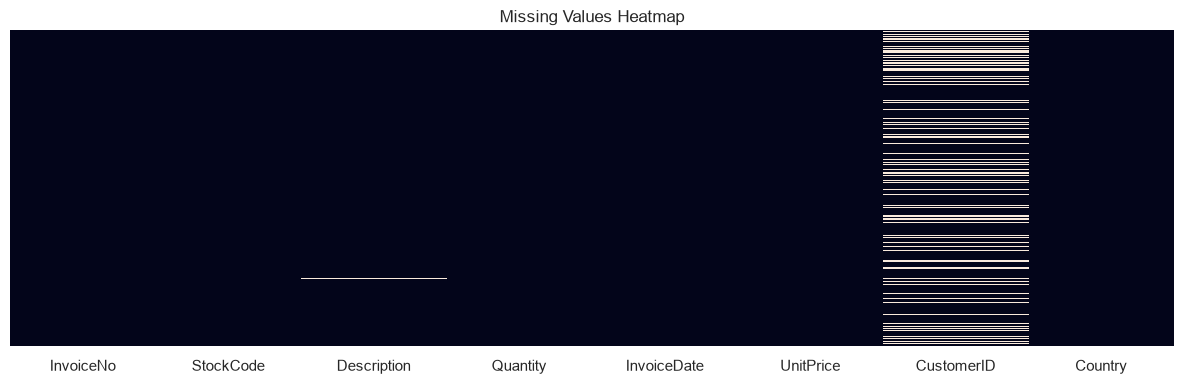

In [355]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [356]:
print("Full-row duplicates:", df.duplicated().sum())
print("Duplicate IDs:", df.duplicated(subset='CustomerID').sum())

Full-row duplicates: 5268
Duplicate IDs: 537536


In [357]:
#Checking duplicate id
all_duplicates = df[df.duplicated(keep=False)]
display(all_duplicates.sort_values(by=['InvoiceNo', 'StockCode']).head(10))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,12/1/2010 11:49,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [358]:
df[df['Country']!="United Kingdom"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,12/1/2010 8:45,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,12/1/2010 8:45,3.75,12583.0,France
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,12/1/2010 8:45,3.75,12583.0,France
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,12/1/2010 8:45,0.85,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,12/1/2010 8:45,0.65,12583.0,France
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [359]:
#Dropping duplicate value
def clean_data(df):
    """Clean the whole dataset within 5 steps"""

    df_clean=df.copy()
    print(f"Initial shape: {df_clean.shape}")   

    df_clean.drop_duplicates(keep='first', inplace=True)                            #Dropping duplicated rows
    print(f"Shape after dropping duplicate values: {df_clean.shape}")

    df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']           #Create TotalPrice row
    print(f"Shape after creating TotalPrice row: {df_clean.shape}")

    df_clean = df_clean[df_clean['Country']=='United Kingdom'].copy()                         #Dropping customer outside the UK
    print(f"Shape after dropping customer outside UK: {df_clean.shape}")
                                    
    df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]     #Dropping cancelled transaction
    print(f"Shape after removing cancellations: {df_clean.shape}")

    df_clean = df_clean.dropna(subset=['CustomerID'])                               #Dropping customers with null values
    df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
    print(f"Shape after dropping null CustomerID: {df_clean.shape}")

    df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]   #Dropping the rest of invalid value
    print(f"Shape after dropping the invalid value values: {df_clean.shape}")

    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])                           #Parse InvoiceDate to DateTime type

    return df_clean

df=clean_data(df)


Initial shape: (541909, 8)
Shape after dropping duplicate values: (536641, 8)
Shape after creating TotalPrice row: (536641, 9)
Shape after dropping customer outside UK: (490300, 9)
Shape after removing cancellations: (482479, 9)
Shape after dropping null CustomerID: (349227, 9)
Shape after dropping the invalid value values: (349203, 9)


In [360]:
# Parse InvoiceDate into DateTime type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [361]:
#Filling Description based on StockCode feature
# desc_mapping = df.dropna(subset=['Description']).drop_duplicates('StockCode').set_index('StockCode')['Description']
# df['Description'] = df['Description'].fillna(df['StockCode'].map(desc_mapping))

# df.dropna(subset=['Description'], inplace=True)

In [362]:
df.info()

df.head()

<class 'pandas.DataFrame'>
Index: 349203 entries, 0 to 541893
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    349203 non-null  str           
 1   StockCode    349203 non-null  str           
 2   Description  349203 non-null  str           
 3   Quantity     349203 non-null  int64         
 4   InvoiceDate  349203 non-null  datetime64[us]
 5   UnitPrice    349203 non-null  float64       
 6   CustomerID   349203 non-null  int64         
 7   Country      349203 non-null  str           
 8   TotalPrice   349203 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 26.6 MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


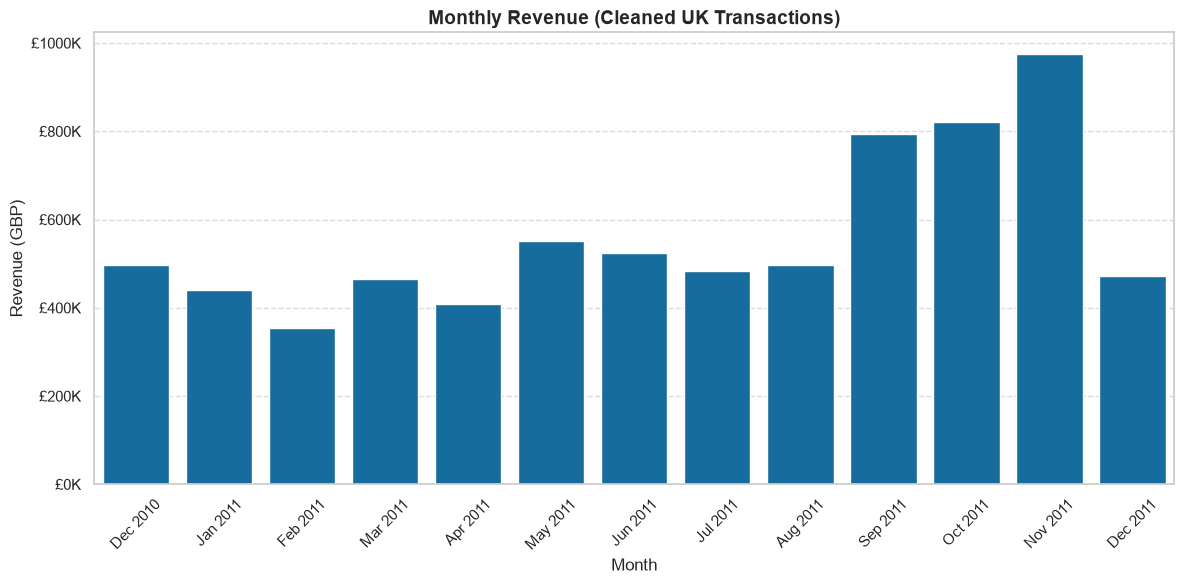

In [363]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

monthly_revenue['Month_Label'] = pd.to_datetime(monthly_revenue['YearMonth']).dt.strftime('%b %Y')

plt.figure(figsize=(12, 6))

ax = sns.barplot(data=monthly_revenue, x='Month_Label', y='TotalPrice', color='#0072B2')

plt.title('Monthly Revenue (Cleaned UK Transactions)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (GBP)', fontsize=12)
plt.xticks(rotation=45)

formatter = ticker.FuncFormatter(lambda x, pos: f'£{int(x/1000)}K')
ax.yaxis.set_major_formatter(formatter)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Observation
- From the chart, we see that the revenue each month from September to November are higher than the rest of the year. 
- This mean there may be a customer segment that only active in that period, which is understandable because it is the holiday period in the UK

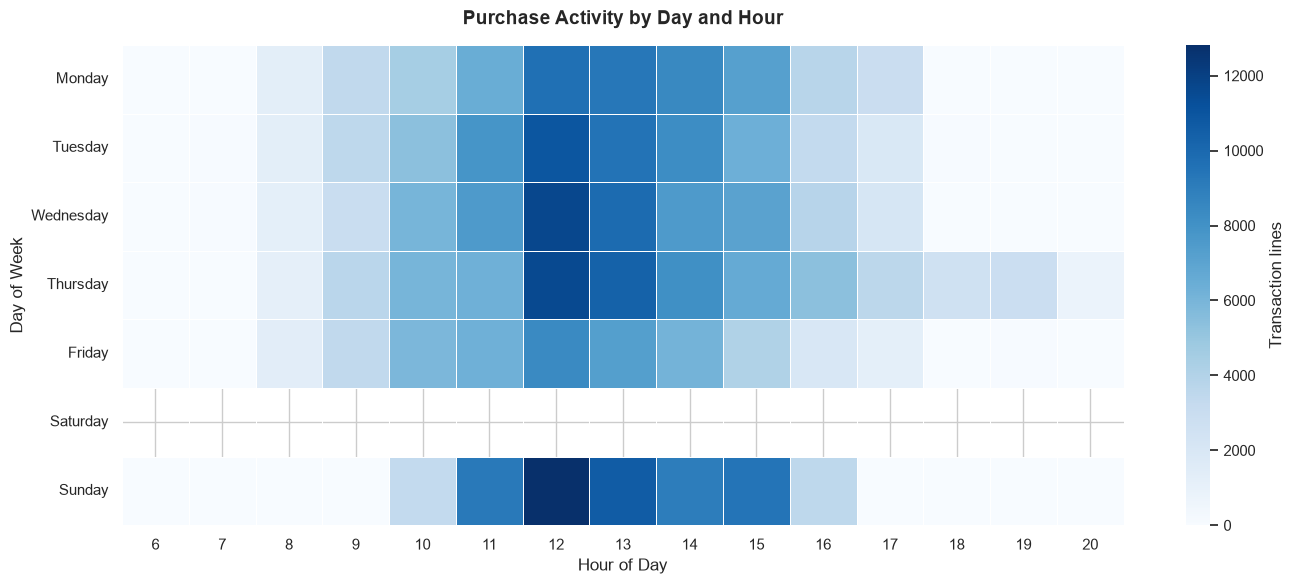

In [364]:
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

activity_matrix = df.groupby(['DayOfWeek', 'Hour']).size().unstack(fill_value=0)

activity_matrix = activity_matrix.reindex(days_order)

plt.figure(figsize=(14, 6))


ax = sns.heatmap(activity_matrix, cmap='Blues', linewidths=.5, 
                 cbar_kws={'label': 'Transaction lines'})

plt.title('Purchase Activity by Day and Hour', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation
- The heatmap showes that the majority of the transaction lie on the office hours (from 9am to 16pm). More over, there is no transaction in Saturday. This mean that there is a huge number of B2B customer other than B2C customer

## Phase 3: RFM Feature Engineering (Preview)

**Objective:** Transform transaction-level data into customer-level RFM features for analysis.

**RFM Framework:**
- **Recency** — Days since last purchase (lower = more engaged)
- **Frequency** — Number of distinct orders (higher = more loyal)
- **Monetary** — Total revenue generated (higher = more valuable)

This is a preview for EDA purposes. The production-ready version will be built in `02_feature_engineering.ipynb`.

In [365]:
# Define reference date as 1 day after the last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date (simulated 'today'): {reference_date}")

# Build RFM table
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"\nRFM table shape: {rfm.shape} — one row per customer")
rfm.head(10)

Reference date (simulated 'today'): 2011-12-10 12:49:00

RFM table shape: (3920, 4) — one row per customer


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,2,11,4196.01
2,12748,1,209,33053.19
3,12749,4,5,4090.88
4,12820,3,4,942.34
5,12821,214,1,92.72
6,12822,71,2,948.88
7,12823,75,5,1759.50
8,12824,60,1,397.12
9,12826,3,7,1474.72


In [366]:
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Recency,3920.0,92.21,99.53,1.00,18.00,51.00,143.00,374.0
Frequency,3920.0,4.25,7.20,1.00,1.00,2.00,5.00,209.0
Monetary,3920.0,1858.42,7478.63,3.75,298.18,644.97,1571.28,259657.3


## Phase 4: Univariate Analysis

**Objective:** Understand the distribution of each RFM feature individually.

**Why this matters for K-Means:**
- K-Means uses **Euclidean distance** and **mean-based centroids**
- Both are sensitive to **skewness** — long tails compress most data into a tiny range, making distance meaningless
- Histograms and box plots give visual evidence to decide whether we need transformations

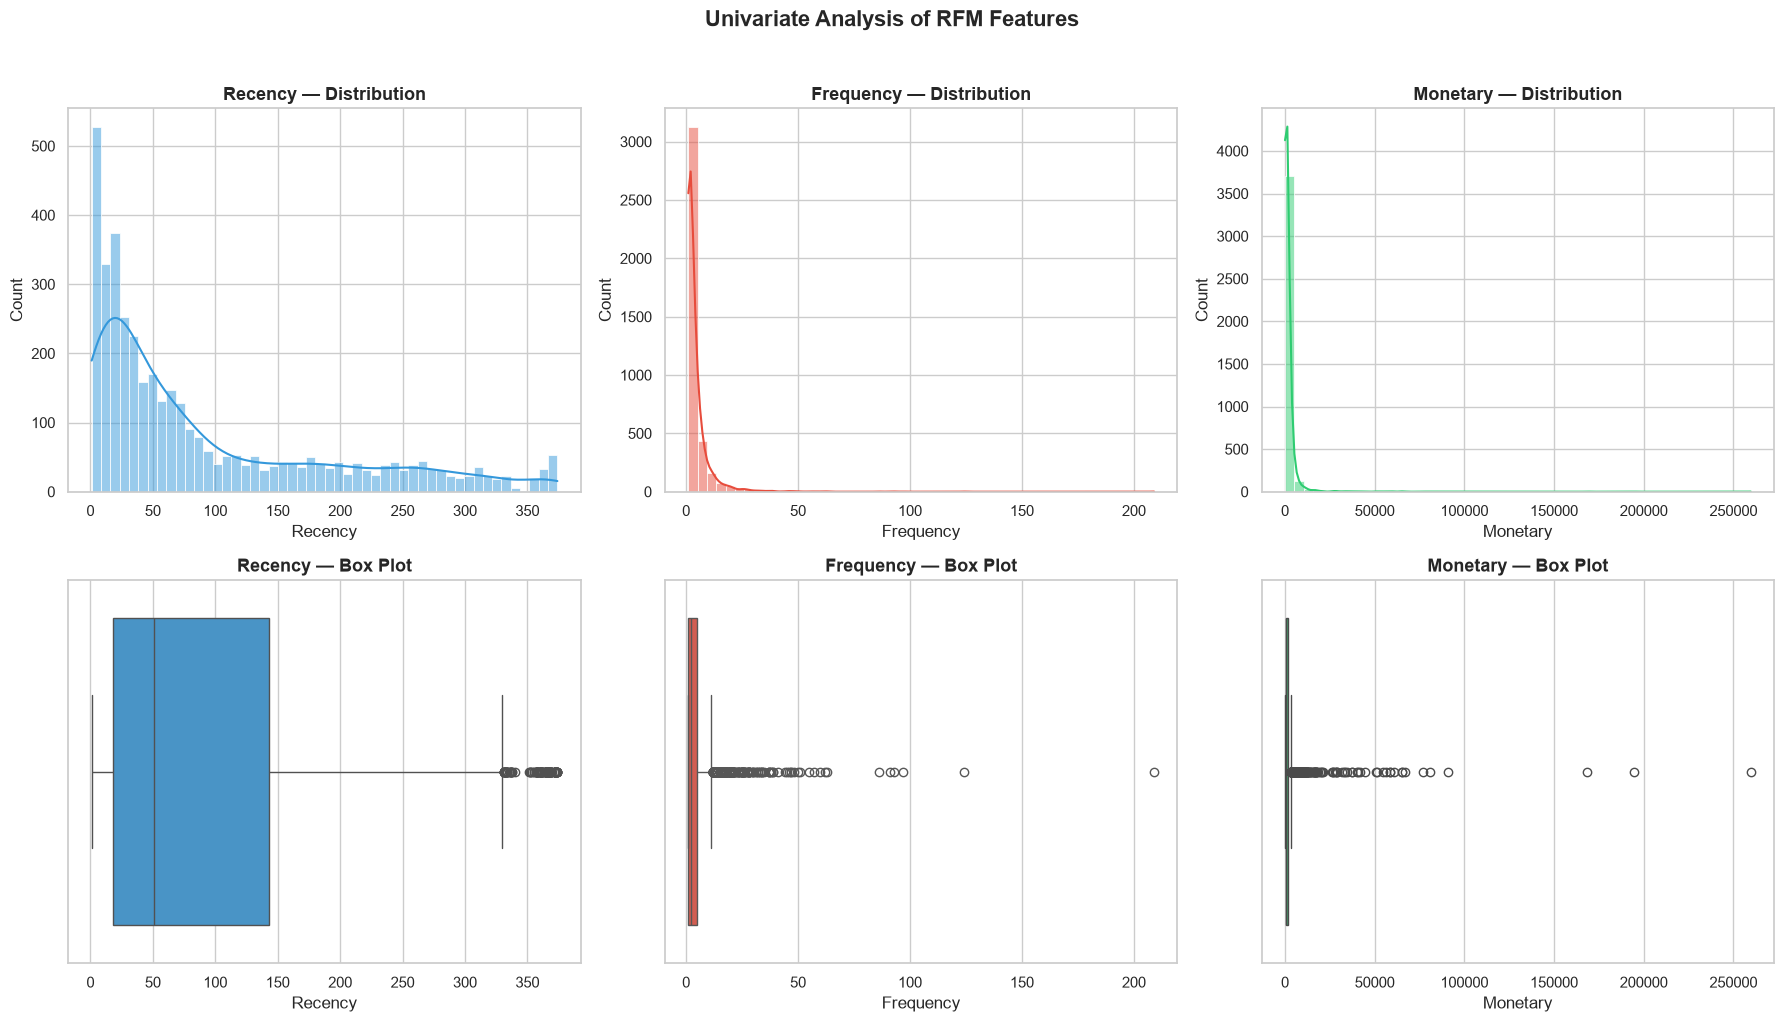

In [367]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    # Histogram + KDE
    sns.histplot(rfm[col], kde=True, ax=axes[0, i], bins=50,
                 color=colors[i], edgecolor='white')
    axes[0, i].set_title(f'{col} — Distribution', fontsize=13, fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

    # Box plot
    sns.boxplot(x=rfm[col], ax=axes[1, i], color=colors[i])
    axes[1, i].set_title(f'{col} — Box Plot', fontsize=13, fontweight='bold')
    axes[1, i].set_xlabel(col)

plt.suptitle('Univariate Analysis of RFM Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [368]:
# Summary statistics with skewness and kurtosis
summary = rfm[['Recency', 'Frequency', 'Monetary']].describe().T
summary['skew'] = rfm[['Recency', 'Frequency', 'Monetary']].skew()
summary['kurtosis'] = rfm[['Recency', 'Frequency', 'Monetary']].kurtosis()
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Recency,3920.0,92.21,99.53,1.00,18.00,51.00,143.00,374.0,1.25,0.44
Frequency,3920.0,4.25,7.20,1.00,1.00,2.00,5.00,209.0,10.75,216.41
Monetary,3920.0,1858.42,7478.63,3.75,298.18,644.97,1571.28,259657.3,20.22,554.87


In [369]:
# Lưu file giao dịch đã làm sạch
df.to_csv('../data/processed/cleaned_transactions.csv', index=False)

# Lưu file RFM (nếu ông muốn giữ lại để làm dashboard hoặc report sau này)
rfm.to_csv('../data/processed/rfm_summary.csv', index=False)

print("Đã lưu Checkpoint thành công vào data/processed/")

Đã lưu Checkpoint thành công vào data/processed/


### Observation: The Right-Skewed Nature of RFM and Its Limitations

**1. Severe Right-Skewed (Long-Tail) Distributions**
As observed in the univariate histograms, the fundamental RFM metrics (Recency, Frequency, Monetary) exhibit a severe right-skewed distribution. The vast majority of the customer base is heavily concentrated in the lower-value regions (e.g., low frequency, low monetary spend), while a very small fraction of high-volume customers extends the tail far to the right. 

**2. The Behavioral Blind Spots of Basic RFM**
While RFM provides a useful macroeconomic snapshot of total customer value, it is purely an aggregative model. It fundamentally misses critical, nuanced behavioral patterns:
* **Seasonality & Purchase Rhythm:** Metrics like Recency and Frequency only measure the *total count* of purchases, completely failing to capture *when* those purchases are concentrated (e.g., customers who only emerge during the year-end holiday season).
* **Returns & Cancellations:** Standard RFM calculations aggregate net value but often mask underlying negative signals, such as systematically high cancellation rates.
* **Basket Composition:** RFM cannot distinguish between a customer who buys one expensive item versus a customer who buys hundreds of cheap items, treating them as identical in the Monetary dimension.

**3. Strategic Conclusion & Next Steps**
Relying exclusively on these three generic metrics will lead to shallow, volume-based clustering. To build highly actionable and distinct marketing personas, we must move beyond basic RFM. We will proceed to the **Feature Engineering** phase to construct a richer, multi-dimensional set of behavioral features that capture purchase rhythms, basket stability, and return lifecycles.

## EDA & Data Cleansing Summary

**1. Data Quality Secured**
We successfully transformed the raw transaction logs into a high-fidelity dataset. By systematically isolating our core market (United Kingdom), removing incomplete records (null `CustomerID`), filtering out internal accounting noise (zero/negative quanityt and prices), and properly handling cancellation invoices, we have established a strictly reliable foundation for behavioral modeling.

**2. The Reality of Customer Spending Distributions**
Our exploratory analysis of fundamental metrics reveals heavily right-skewed distributions. The vast majority of the customer base interacts and spends at lower thresholds, while a highly concentrated, low-volume group of "whales" drives a disproportionate amount of total revenue. 

**3. The Limitations of Basic RFM**
While traditional RFM (Recency, Frequency, Monetary) analysis successfully highlights the Pareto principle within our data, it is insufficient for advanced segmentation. RFM is purely an aggregative model; it cannot capture crucial behavioral nuances such as when purchases are concentrated (seasonal spikes) or identify underlying return lifecycles. 

**➡️ Next Step:** 
To build a robust K-Means clustering model that yields truly actionable marketing personas, we must move beyond these basic aggregates. In the next phase (`02_feature_engineering.ipynb`), we will synthesize advanced behavioral features to capture the true, multi-dimensional purchasing rhythms and basket stability of our customers.